Introduction du projet à noter

In [57]:
#Import
import pandas as p
import matplotlib.pyplot as plt
import collections as col
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np

In [40]:
#Initialisation des variables et extraction des donnees

csvF = p.read_csv("./train.csv");
context = csvF["Context"]
response = csvF["Response"]

In [ ]:
context = context.str.lower()
response= response.str.lower()

context  = context.str.replace('\'', "")
response  = response.str.replace('\'', "")

print(context)
print(response)

0       im going through some things with my feelings ...
1       im going through some things with my feelings ...
2       im going through some things with my feelings ...
3       im going through some things with my feelings ...
4       im going through some things with my feelings ...
                              ...                        
3507    my grandsons step-mother sends him to school w...
3508    my boyfriend is in recovery from drug addictio...
3509    the birth mother attempted suicide several tim...
3510    i think adult life is making him depressed and...
3511    i just took a job that requires me to travel f...
Name: Context, Length: 3512, dtype: str
0       if everyone thinks you're worthless, then mayb...
1       hello, and thank you for your question and see...
2       first thing i'd suggest is getting the sleep y...
3       therapy is essential for those that are feelin...
4       i first want to let you know that you are not ...
                              ..

In [42]:
#Trouver le nombre de patient

contextD= p.DataFrame(context)
contextDistinct = contextD.drop_duplicates(contextD)

print(len(contextDistinct))

995


In [43]:
#Trouver le nombre de therapeute
reponseD= p.DataFrame(response)
reponseDistinct = reponseD.drop_duplicates(reponseD)

print(len(reponseDistinct))

2472


In [44]:
#Nombre de conversation par therapeute

#group by par phrase de therapeute avec un compte afficher
conversationTherapeute = csvF
conversationTherapeute = conversationTherapeute.drop_duplicates()
conversationTherapeute = conversationTherapeute.groupby(["Response"]).count()
moyenneT = conversationTherapeute.Context.mean()
print(moyenneT)

1.1088628085795225


In [45]:
#Nombre d'echange moyen par conversation
conversation = csvF
conversation = conversation.drop_duplicates()
conversation = conversation.groupby(["Context"]).count()
moyenne = conversation.Response.mean()
print(moyenne)

2.7537688442211055


In [46]:
#Frequence mot dans les patients

contextDictionnaire = p.DataFrame(context)
contextDictionnaire = contextDictionnaire.drop_duplicates()
listeIndex =contextDictionnaire.index

#etape 1 : fusionner toutes les cellules de la table dans une seule ou faire une colonne avec un mot par case

contextSplit = contextDictionnaire["Context"].str.split(" ")
listeSplit = []

for i in range (len(contextSplit) ):
    if i in listeIndex :
        listeSplit = listeSplit + contextSplit[i]

#etape 2 : recuperer le nombre total de mot

print (len(listeSplit))

#etape 3 : group by mot, avec le compte d'apparition du mot

compte = col.Counter(listeSplit)
print(compte.values())
print(compte.keys())

compteSorted = compte.most_common()
print(compteSorted)

#etape 4 : colonne frequence avec la frequence d'apparition de chaque mot
listeFrequence = []
for i in range (len(compteSorted) - 1) :
    listeFrequence.append((compteSorted[i][0], compteSorted[i][1], compteSorted[i][1]/len(listeSplit)))

print(listeFrequence)

23610
dict_values([235, 42, 23, 27, 38, 258, 630, 11, 871, 25, 1680, 3, 11, 131, 18, 202, 58, 111, 101, 5, 5, 111, 1, 177, 77, 64, 15, 100, 1, 2, 55, 21, 750, 6, 5, 101, 24, 4, 90, 6, 22, 280, 39, 1, 292, 93, 12, 10, 1, 505, 2, 8, 1, 46, 1, 1, 2, 126, 1, 1, 9, 32, 1, 14, 5, 8, 2, 15, 120, 2, 11, 204, 14, 1, 1, 73, 4, 26, 9, 18, 2, 242, 1, 30, 13, 41, 4, 20, 39, 9, 9, 7, 15, 2, 84, 63, 1, 38, 22, 203, 108, 4, 2, 9, 38, 107, 199, 144, 11, 125, 54, 1, 276, 1, 10, 11, 387, 2, 99, 5, 1, 4, 8, 18, 2, 67, 17, 1, 22, 2, 5, 6, 12, 2, 1, 50, 6, 4, 8, 1, 1, 6, 8, 1, 7, 11, 156, 81, 5, 23, 5, 1, 1, 1, 10, 12, 2, 3, 91, 28, 12, 2, 18, 16, 35, 11, 149, 13, 38, 10, 89, 70, 5, 8, 17, 1, 51, 8, 2, 15, 7, 1, 206, 6, 5, 1, 46, 1, 1, 1, 2, 2, 3, 1, 1, 14, 2, 17, 5, 50, 1, 99, 1, 1, 19, 8, 16, 4, 6, 2, 72, 7, 7, 1, 4, 1, 3, 7, 1, 4, 1, 36, 1, 4, 1, 1, 1, 1, 1, 128, 20, 31, 1, 1, 1, 19, 1, 41, 15, 1, 1, 1, 9, 3, 27, 2, 1, 1, 42, 6, 5, 1, 1, 6, 7, 2, 2, 22, 66, 18, 1, 115, 130, 1, 10, 16, 1, 260, 3, 1, 1, 2,

In [47]:
#Frequence mot pour tout les therapeutes

responseDictionnaire = p.DataFrame(response)
responseDictionnaire = responseDictionnaire.drop_duplicates()
listeIndex =responseDictionnaire.index

#etape 1 : fusionner toutes les cellules de la table dans une seule ou faire une colonne avec un mot par case

responseSplit = responseDictionnaire["Response"].str.split(" ")
listeSplitR = []

for i in range (len(responseSplit) ):
    if i in listeIndex :
        if isinstance(responseSplit[i],list) :
            listeSplitR = listeSplitR + responseSplit[i]

#etape 2 : recuperer le nombre total de mot

print (len(listeSplitR))

#etape 3 : group by mot, avec le compte d'apparition du mot

compteR = col.Counter(listeSplitR)
print(compteR.values())
print(compteR.keys())

compteSortedR = compteR.most_common()
print(compteSortedR)

#etape 4 : colonne frequence avec la frequence d'apparition de chaque mot
listeFrequenceR = []
for i in range (len(compteSortedR) - 1) :
    listeFrequenceR.append((compteSortedR[i][0], compteSortedR[i][1], compteSortedR[i][1]/len(listeSplitR)))

print(listeFrequenceR)

366658
dict_values([2432, 86, 20, 588, 10, 770, 242, 14381, 643, 14989, 655, 331, 915, 18, 894, 1, 9710, 117, 24, 4936, 566, 8309, 513, 52, 6831, 81, 24, 1, 3092, 368, 2, 9554, 213, 327, 265, 2290, 182, 211, 4, 3801, 1, 168, 1, 4479, 532, 2, 35, 2, 11, 66, 1182, 6595, 61, 62, 6551, 514, 636, 761, 25, 787, 4, 120, 535, 12, 922, 2, 3907, 17, 626, 273, 1500, 2092, 96, 2695, 17, 1, 461, 272, 9, 21, 30, 12, 88, 1167, 90, 193, 1413, 316, 1190, 40, 474, 1, 1, 222, 7349, 599, 7, 1645, 212, 5, 320, 267, 5, 46, 70, 3510, 194, 61, 42, 1882, 91, 22, 14, 30, 380, 66, 48, 2640, 97, 23, 945, 130, 153, 1, 1259, 39, 330, 317, 651, 182, 56, 4, 22, 13, 309, 113, 212, 817, 415, 1180, 466, 29, 223, 1, 494, 5, 41, 26, 43, 4, 419, 43, 36, 58, 654, 49, 487, 414, 180, 64, 54, 325, 407, 125, 157, 55, 1, 2777, 115, 117, 1372, 1, 2, 753, 4, 1, 344, 5, 60, 1201, 125, 85, 1199, 45, 138, 287, 87, 117, 106, 260, 28, 640, 46, 55, 163, 122, 187, 128, 25, 122, 8, 35, 30, 373, 51, 1, 127, 51, 12, 27, 182, 35, 2447, 4, 59

In [48]:
#Dictionnaire de mot (avec la frequence pour chaque mot) (sans retrait de ligne)
dictionnaireFusion = compte | compteR
dictionnaireSorted = dictionnaireFusion.most_common()
totalMot = len(listeSplit) + len(listeSplitR)
print(totalMot)
print (dictionnaireSorted)
listeFrequenceF = []
for i in range (len(dictionnaireSorted) - 1) :
    listeFrequenceF.append((dictionnaireSorted[i][0], dictionnaireSorted[i][1], dictionnaireSorted[i][1]/totalMot))

print(listeFrequenceF)

390268
[('to', 14989), ('you', 14381), ('the', 9710), ('and', 9554), ('a', 8309), ('your', 7349), ('is', 6831), ('of', 6595), ('that', 6551), ('in', 4936), ('are', 4479), ('with', 3907), ('be', 3801), ('for', 3510), ('it', 3408), ('can', 3092), ('or', 2777), ('this', 2695), ('have', 2640), ('i', 2447), ('if', 2432), ('what', 2375), ('not', 2290), ('as', 2162), ('about', 2092), ('on', 1882), ('may', 1645), ('will', 1558), ('feel', 1500), ('do', 1413), ('they', 1372), ('would', 1349), ('like', 1259), ('we', 1253), ('help', 1201), ('how', 1199), ('more', 1190), ('some', 1182), ('there', 1180), ('from', 1167), ('when', 1149), ('who', 1127), ('but', 1108), ('he', 1080), ('yourself', 951), ('at', 945), ('an', 930), ('so', 922), ('people', 915), ('out', 894), ('know', 878), ('time', 845), ('want', 842), ('other', 833), ('one', 817), ('by', 815), ('their', 787), ('get', 781), ('her', 774), ('being', 771), ('then', 770), ('relationship', 762), ('good', 761), ('also', 753), ('therapist', 752), (

In [49]:
#Identification sujet majeurs : lexique de mon choix
donneeLexique = p.DataFrame(context)
donneeLexique = donneeLexique.drop_duplicates()

lexiqueD = ["depress", "sad", "suicide", "worthless", "anxie", "bothering","diminish", "dissapoint"]
lexiqueJ = ["joy", "happy", "glad", "delight", "pleasure", "relief", "entertainment"]

listeD = []
listeJ = []

for i in range (len(lexiqueD)):
    listeD.append(donneeLexique[donneeLexique['Context'].str.contains(lexiqueD[i])])
compteD = len(listeD)

listeDFinal = []
for i in range (len(listeD)) :
    ligne = listeD[i]["Context"].tolist()
    for j in range (len(ligne)) :
        if ligne[j] not in listeDFinal :
            listeDFinal.append(ligne[j])

print (len(listeDFinal))

for i in range (len(lexiqueJ)):
    listeJ.append(donneeLexique[donneeLexique['Context'].str.contains(lexiqueJ[i])])
compteJ = len(listeJ)

listeJFinal = []
for i in range (len(listeJ)) :
    ligne = listeJ[i]["Context"].tolist()
    for j in range (len(ligne)) :
        
        if ligne[j] not in listeJFinal :
            listeJFinal.append(ligne[j])

print (len(listeJFinal))


197
86


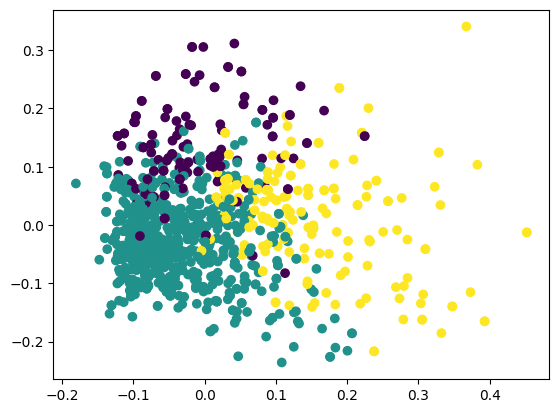


Cluster  0  :
['love', 'says', 'guy', 'time', 'just', 'relationship', 'years', 'want', 'ago', 'got', 'sex', 'like', 'year', 'doesn', 'don', 'really', 've', 'said', 'loves', 'family']

Cluster  1  :
['feel', 'like', 've', 'just', 'years', 'want', 'time', 'help', 'boyfriend', 'things', 'anxiety', 'having', 'think', 'life', 'people', 'need', 'going', 'child', 'depression', 'family']

Cluster  2  :
['don', 'know', 'feel', 'like', 'want', 'really', 'people', 'just', 've', 'tell', 'talk', 'relationship', 'stop', 'way', 'wrong', 'life', 'time', 'say', 'girl', 'make']
0       i'm going through some things with my feelings...
23      i have so many issues to address. i have a his...
70      i have been feeling more and more down for ove...
72      i’m facing severe depression and anxiety and i...
81      how can i get to a place where i can be conten...
                              ...                        
3446    what am i doing wrong? my wife and i are fight...
3491    we rent from from 

In [68]:
#Identification sujet majeurs : cluster de mot

tfidf = TfidfVectorizer(stop_words='english')
corpusPatient = context
corpusTherapeute = response

corpusPatient = corpusPatient.drop_duplicates()
corpusTherapeute = corpusTherapeute.drop_duplicates()

vec = tfidf.fit_transform(corpusPatient.to_list())
vecteur = p.DataFrame(vec.todense(), columns=tfidf.get_feature_names_out())

kmeans = KMeans(n_clusters=3)
ymeans = kmeans.fit_predict(vec)

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(vec.toarray())

plt.figure()
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=ymeans)

plt.show()

df = p.DataFrame({
    "text": corpusPatient.reset_index(drop=True),
    "cluster": ymeans
})

feature_names = tfidf.get_feature_names_out()

for i in range(kmeans.n_clusters) :
    indice = np.where(ymeans==i)
    mean_tfidf = vec[indice].mean(axis=0)
    mean_tfidf = np.asarray(mean_tfidf).flatten()

    top_indices = mean_tfidf.argsort()[::-1][:20]
    top_words = [feature_names[j] for j in top_indices]

    print("\nCluster ", i, " :")
    print(top_words)

print (corpusPatient)

In [ ]:
#Identification sujet majeurs : word embedding

In [ ]:
#Identification sujet majeurs : modele d'extraction de sujet LDA